# Bragg-edge imaging with ODIN

This notebook illustrates how to convert recorded events on the ODIN detector to a single wavelength spectrum,
revealing a Bragg edge in the data.
WFM mode was used in the chopper cascade.

In [1]:
import scipp as sc
from ess.reduce import unwrap
from ess import odin
import ess.odin.data  # noqa: F401
from ess.imaging.types import *

## Create and configure the workflow

In [2]:
wf = odin.OdinBraggEdgeWorkflow(wavelength_from="analytical")

wf[Filename[SampleRun]] = odin.data.iron_simulation_sample_small()
wf[NeXusDetectorName] = "event_mode_detectors/timepix3"

### Patch the choppers in the file

The chopper settings in the file contain errors. We patch them here, but note that **this step should go away in the future**.

In [3]:
from ess.odin.beamline import choppers

disk_choppers = choppers(source_position=wf.compute(Position[snx.NXsource, SampleRun]))
wf[unwrap.DiskChoppers[SampleRun]] = disk_choppers

## First look at the data

We load the raw detector data and perform a quick visualization of the `event_time_offset` spectrum.

In [4]:
tmpx3 = wf.compute(RawDetector[SampleRun])
tmpx3

<scipp.DataArray>
Dimensions: Sizes[x_pixel_offset:4096, y_pixel_offset:4096, ]
Coordinates:
* detector_number             int32        <no unit>  (x_pixel_offset, y_pixel_offset)  [0, 1, ..., 16777214, 16777215]
* position                  vector3              [m]  (x_pixel_offset, y_pixel_offset)  [(-0.00703828, -0.00703828, 0), (-0.00703828, -0.00703484, 0), ..., (0.00703828, 0.00703484, 0), (0.00703828, 0.00703828, 0)]
* x_pixel_offset            float32              [m]  (x_pixel_offset)  [-0.00703828, -0.00703484, ..., 0.00703484, 0.00703828]
* y_pixel_offset            float32              [m]  (y_pixel_offset)  [-0.00703828, -0.00703484, ..., 0.00703484, 0.00703828]
Data:
                          DataArrayView        <no unit>  (x_pixel_offset, y_pixel_offset)  binned data: dim='event', content=DataArray(
          dims=(event: 1000000),
          data=float32[counts],
          coords={'event_time_offset':float64[ns], 'event_time_zero':datetime64[ns]})

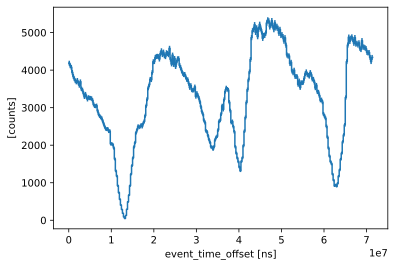

In [5]:
tmpx3.bins.concat().hist(event_time_offset=300).plot()

## Compute neutron wavelengths

We will now use the workflow to compute the neutron wavelengths using a lookup table built from the beamline chopper information.

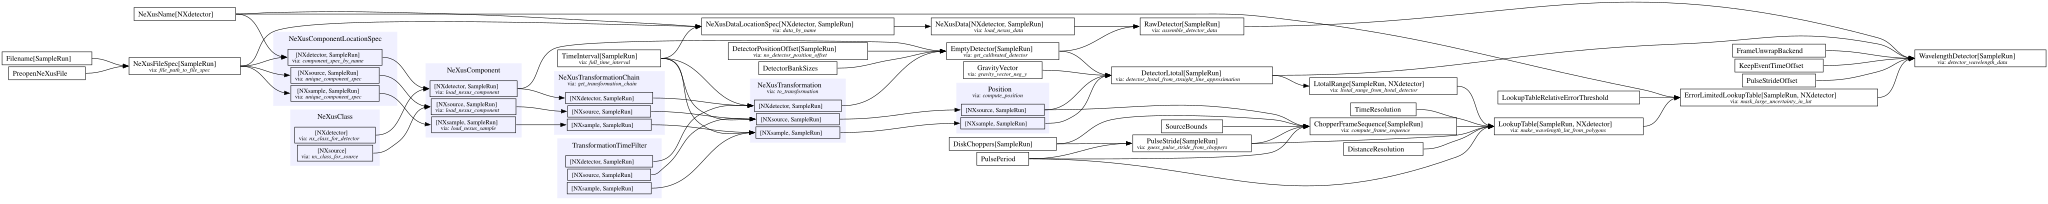

In [6]:
wf.visualize(WavelengthDetector[SampleRun], graph_attr={"rankdir": "LR"})

### Inspect the lookup table

It is always a good idea to quickly plot the wavelength lookup table, as a sanity check.

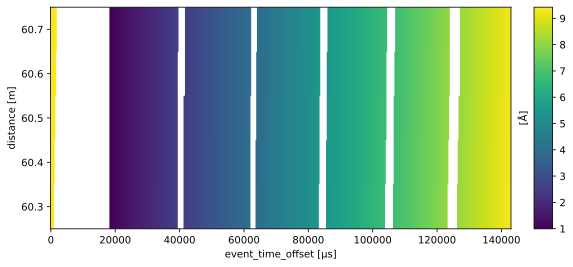

In [7]:
table = wf.compute(unwrap.LookupTable[SampleRun, NXdetector])
table.plot(figsize=(9, 4))

### Compute neutron wavelengths

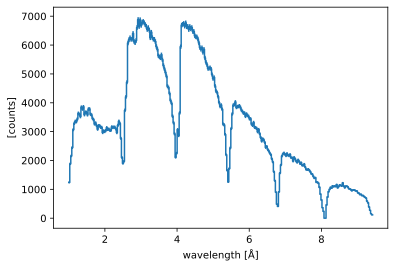

In [8]:
sample_wavs = wf.compute(WavelengthDetector[SampleRun])

sample_wavs.bins.concat().hist(wavelength=300).plot()

## Process the open-beam run

We now reuse the same workflow to process the open-beam run that will be used later for normalization.

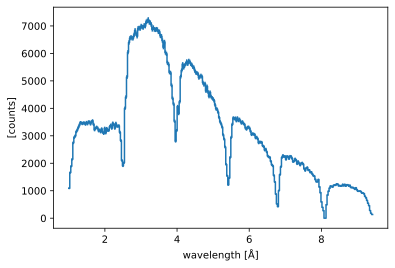

In [9]:
wf[Filename[OpenBeamRun]] = odin.data.iron_simulation_ob_small()

# Also need to patch choppers here
wf[unwrap.DiskChoppers[OpenBeamRun]] = disk_choppers

openbeam_wavs = wf.compute(WavelengthDetector[OpenBeamRun])

openbeam_wavs.bins.concat().hist(wavelength=300).plot()

## Select region of interest by masking outer regions

Making a 2D histogram of the data shows a dark square region in the centre of the detector panel;
this is the region of interest, where the square sample has absorbed neutrons.

In [10]:
# ODIN timepix has 4096x4096 pixels by default, which is too many to visualize without `ignore_size=True` option.
# we will use 256x256 pixels instead for visualization in the documentation.
vis_resolution = {"x_pixel_offset": 256, "y_pixel_offset": 256}

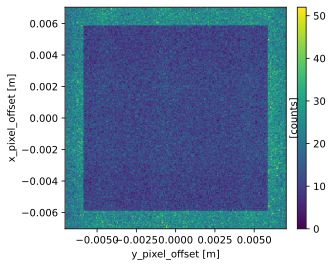

In [11]:
sample_wavs.hist(vis_resolution).plot(aspect='equal')

The brighter areas around the edges are regions where neutrons did not travel through the sample.
We thus want to mask those out using masking rules based on the spatial coordinates of the data:

In [12]:
wf[MaskingRules] = {
    'x_pixel_offset': lambda x: (x < sc.scalar(-5.8e-3, unit='m').to(unit=x.unit)) | (x > sc.scalar(5.8e-3, unit='m').to(unit=x.unit)),
    'y_pixel_offset': lambda y: (y < sc.scalar(-5.8e-3, unit='m').to(unit=y.unit)) | (y > sc.scalar(5.8e-3, unit='m').to(unit=y.unit))
}

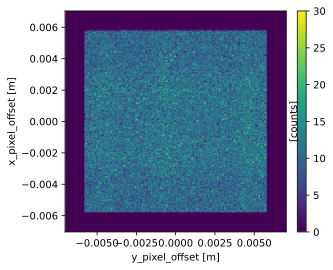

In [13]:
masked = wf.compute(CorrectedDetector[SampleRun])

masked.hist(vis_resolution).plot(aspect='equal')

## Normalize to open beam

Finally, we use the masked sample and open-beam data to obtain a normalized signal,
which reveals the Fe Bragg edges:

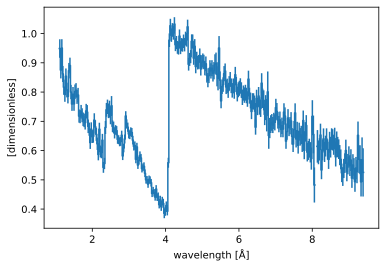

In [14]:
wbins = sc.linspace('wavelength', 1.1, 9.4, 301, unit='angstrom')

normalized = (
        wf.compute(CorrectedDetector[SampleRun]).bins.concat().hist(wavelength=wbins) /
        wf.compute(CorrectedDetector[OpenBeamRun]).bins.concat().hist(wavelength=wbins)
)

normalized.plot()

## Save the final result

In [15]:
from scippneutron.io import save_xye

to_disk = normalized.copy(deep=False)
to_disk.coords['wavelength'] = sc.midpoints(to_disk.coords['wavelength'])

save_xye('fe_bragg_edge.xye', to_disk)